In [2]:
import pandas as pd
import time
from datetime import datetime
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
from mpl_toolkits.mplot3d import Axes3D

In [3]:
import os

project_root = r"C:\Users\DELL\Desktop\room208\Ankit\Car_prize_forcasting"

os.chdir(project_root)

print(os.getcwd())

C:\Users\DELL\Desktop\room208\Ankit\Car_prize_forcasting


In [4]:
df = pd.read_csv(r"data\csvs\Cars24.csv")
df.drop('Unnamed: 0',axis=1,inplace=True)
df.head()

,year,name,variant,price,emi,driven_km,fuel,transmission,registration,location,city
0,2023,Nissan MAGNITE,XL,517000.0,9135.0,41774,Petrol,Manual,TS-36,"Kompally, Hyderabad",Hyderabad
1,2022,Maruti Swift,VXI,519000.0,9156.0,40355,Petrol,Manual,TS-15,"Upperpally, Attapur, Hyderabad",Hyderabad
2,2020,Renault Kwid,CLIMBER 1.0 (O),282000.0,4982.0,66791,Petrol,Manual,TS-15,"Kompally, Hyderabad",Hyderabad
3,2023,Maruti Swift,ZXI,593000.0,10470.0,62871,Petrol,Manual,TS-07,"Upperpally, Attapur, Hyderabad",Hyderabad
4,2019,KIA SELTOS,HTK 1.5 PETROL,661000.0,11665.0,70038,Petrol,Manual,TS-10,"Upperpally, Attapur, Hyderabad",Hyderabad


### Removing duplicated rows

In [5]:
df = df.drop_duplicates(keep='first')

### Finding number of "Missing / NAN" values

In [5]:
df.isnull().sum().sort_values(ascending=False)

transmission    96
registration    13
emi              3
year             0
name             0
variant          0
price            0
driven_km        0
fuel             0
location         0
city             0
dtype: int64

### Removing the rows which have missing values

In [6]:
columns = ['transmission','registration']
df = df.dropna(subset = columns).reset_index(drop=False)

In [7]:
df.isnull().sum()

index           0
year            0
name            0
variant         0
price           0
emi             3
driven_km       0
fuel            0
transmission    0
registration    0
location        0
city            0
dtype: int64

In [8]:
df.columns

Index(['index', 'year', 'name', 'variant', 'price', 'emi', 'driven_km', 'fuel',
       'transmission', 'registration', 'location', 'city'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 272 entries, 0 to 271
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   index         272 non-null    int64  
 1   year          272 non-null    int64  
 2   name          272 non-null    object 
 3   variant       272 non-null    object 
 4   price         272 non-null    float64
 5   emi           269 non-null    float64
 6   driven_km     272 non-null    int64  
 7   fuel          272 non-null    object 
 8   transmission  272 non-null    object 
 9   registration  272 non-null    object 
 10  location      272 non-null    object 
 11  city          272 non-null    object 
dtypes: float64(2), int64(3), object(7)
memory usage: 25.6+ KB


In [10]:
df.index

RangeIndex(start=0, stop=272, step=1)

In [11]:
df.dtypes

index             int64
year              int64
name             object
variant          object
price           float64
emi             float64
driven_km         int64
fuel             object
transmission     object
registration     object
location         object
city             object
dtype: object

In [12]:
df.describe(include='all')

,index,year,name,variant,price,emi,driven_km,fuel,transmission,registration,location,city
count,272.000000,272.000000,272,272,2.720000e+02,269.000000,272.000000,272,272,272,272,272
unique,NaN,NaN,62,143,NaN,NaN,NaN,3,1,92,24,5
top,NaN,NaN,Hyundai Grand i10,VXI,NaN,NaN,NaN,Petrol,Manual,TS-08,"Kompally, Hyderabad",Hyderabad
freq,NaN,NaN,18,19,NaN,NaN,NaN,214,272,26,51,119
mean,183.786765,2018.261029,NaN,NaN,4.753235e+05,10419.126394,62802.463235,NaN,NaN,NaN,NaN,NaN
std,114.081114,3.120263,NaN,NaN,2.433125e+05,5079.359031,27407.158692,NaN,NaN,NaN,NaN,NaN
min,0.000000,2012.000000,NaN,NaN,1.290000e+05,2815.000000,4762.000000,NaN,NaN,NaN,NaN,NaN
25%,77.500000,2016.000000,NaN,NaN,2.862500e+05,6956.000000,45315.750000,NaN,NaN,NaN,NaN,NaN
50%,190.500000,2018.000000,NaN,NaN,4.290000e+05,9695.000000,59895.000000,NaN,NaN,NaN,NaN,NaN
75%,285.250000,2021.000000,NaN,NaN,6.072500e+05,12666.000000,78385.250000,NaN,NaN,NaN,NaN,NaN


##### Some statistical details can't be calculated for object type so it gives 'NaN' values

In [13]:
df = df.drop('index',axis=1)

In [14]:
df.city.unique()

array(['Hyderabad', 'Delhi', 'Mumbai', 'Bangalore', 'Chennai'],
      dtype=object)

In [15]:
df

,year,name,variant,price,emi,driven_km,fuel,transmission,registration,location,city
0,2023,Nissan MAGNITE,XL,517000.0,9135.0,41774,Petrol,Manual,TS-36,"Kompally, Hyderabad",Hyderabad
1,2022,Maruti Swift,VXI,519000.0,9156.0,40355,Petrol,Manual,TS-15,"Upperpally, Attapur, Hyderabad",Hyderabad
2,2020,Renault Kwid,CLIMBER 1.0 (O),282000.0,4982.0,66791,Petrol,Manual,TS-15,"Kompally, Hyderabad",Hyderabad
3,2023,Maruti Swift,ZXI,593000.0,10470.0,62871,Petrol,Manual,TS-07,"Upperpally, Attapur, Hyderabad",Hyderabad
4,2019,KIA SELTOS,HTK 1.5 PETROL,661000.0,11665.0,70038,Petrol,Manual,TS-10,"Upperpally, Attapur, Hyderabad",Hyderabad
...,...,...,...,...,...,...,...,...,...,...,...
267,2016,Datsun Redi Go,S,203000.0,4516.0,72632,Petrol,Manual,TN-01,Sholinganallur,Chennai
268,2014,Hyundai Grand i10,SPORTZ 1.2 KAPPA VTVT,350000.0,11638.0,39773,Petrol,Manual,TN-13,Sholinganallur,Chennai
269,2021,KIA SONET,HTX 1.0 IMT,650000.0,11467.0,87623,Petrol,Manual,TN-13,Sholinganallur,Chennai
270,2021,Skoda KUSHAQ,STYLE 1.0L TSI MT,788000.0,13913.0,79188,Petrol,Manual,TN-05,"Nexus Vijaya Mall, Vadapalani",Chennai


C:\Users\DELL\AppData\Local\Temp\ipykernel_28588\1242579450.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  a = sns.countplot(x = 'city',data=df,edgecolor='black',palette='coolwarm_r')


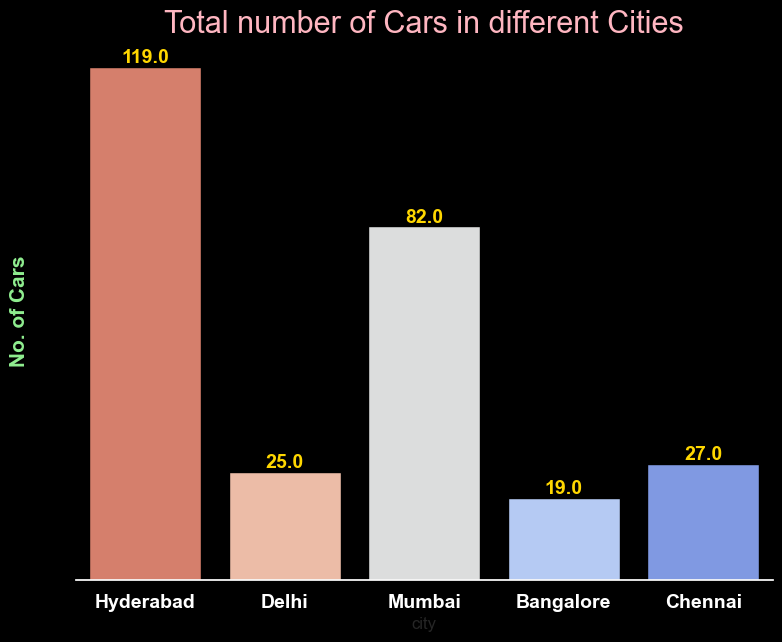

In [24]:
plt.figure(facecolor='black',figsize=(9,7))
sns.set(rc={'figure.figsize':(8,6)})
a = sns.countplot(x = 'city',data=df,edgecolor='black',palette='coolwarm_r')
for p in a.patches:
    a.annotate(format(p.get_height(),'.1f'),(p.get_x()+p.get_width()/2.,p.get_height()),ha='center',
              va='center',xytext=(0,6.5),textcoords='offset points',fontsize=14,color='gold',fontweight='bold')
plt.title("Total number of Cars in different Cities",fontsize=22,color='lightpink')
plt.xticks(rotation=0,fontsize=14,fontweight='bold',color='white')
plt.yticks(fontsize=12,fontweight='bold',color='black')
a.set_facecolor('black')
a.set_ylabel("No. of Cars", fontsize =15, color='lightgreen',fontweight='bold')
a.spines['left'].set_color('black')
a.spines['top'].set_color('black')
a.spines['bottom'].set_color('white')
a.spines['right'].set_color('black')
plt.grid(False)

## 1) Percentage of cars available for sale in different cities

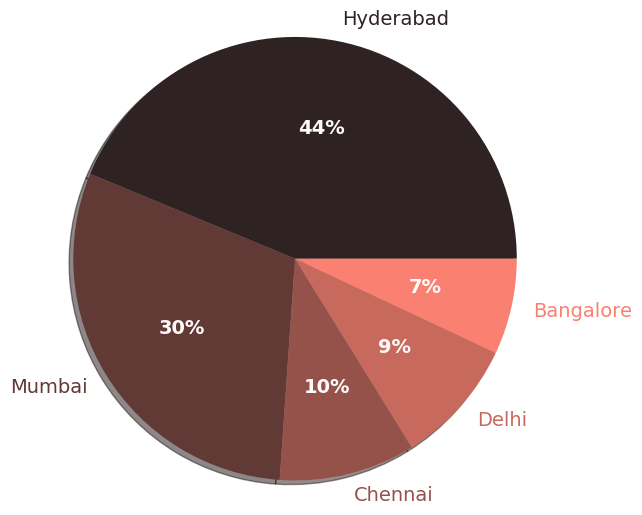

In [16]:
# count = df['city'].value_counts()
# count = count.reset_index().rename(columns={'city':'Count','index':'city'})
count = df['city'].value_counts().reset_index()

count.columns = ['city', 'Count']
colors = sns.set_palette('dark:salmon',5)
patches,text, pcts= plt.pie(x='Count',labels='city',autopct='%1.0f%%',data=count,colors=colors,radius=1.5,shadow=True,
                    textprops={'fontsize': 14})
for i, patch in enumerate(patches):
    text[i].set_color(patch.get_facecolor())
plt.setp(pcts, color='snow',fontweight='bold')
plt.show()

In [16]:
brand_count = df['name'].value_counts().sort_values(ascending=False).reset_index()

In [19]:
brand_count.rename(columns = {'index':'Brand'}, inplace = True)

In [21]:
brand_count.head()

,name,count
0,Hyundai Grand i10,18
1,Renault Kwid,17
2,Tata NEXON,17
3,Maruti Swift,16
4,Maruti Baleno,11


C:\Users\DELL\AppData\Local\Temp\ipykernel_18404\1247359924.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  a = sns.barplot(y ='name',x='count',data=brand_count,palette='spring_r',edgecolor='black')


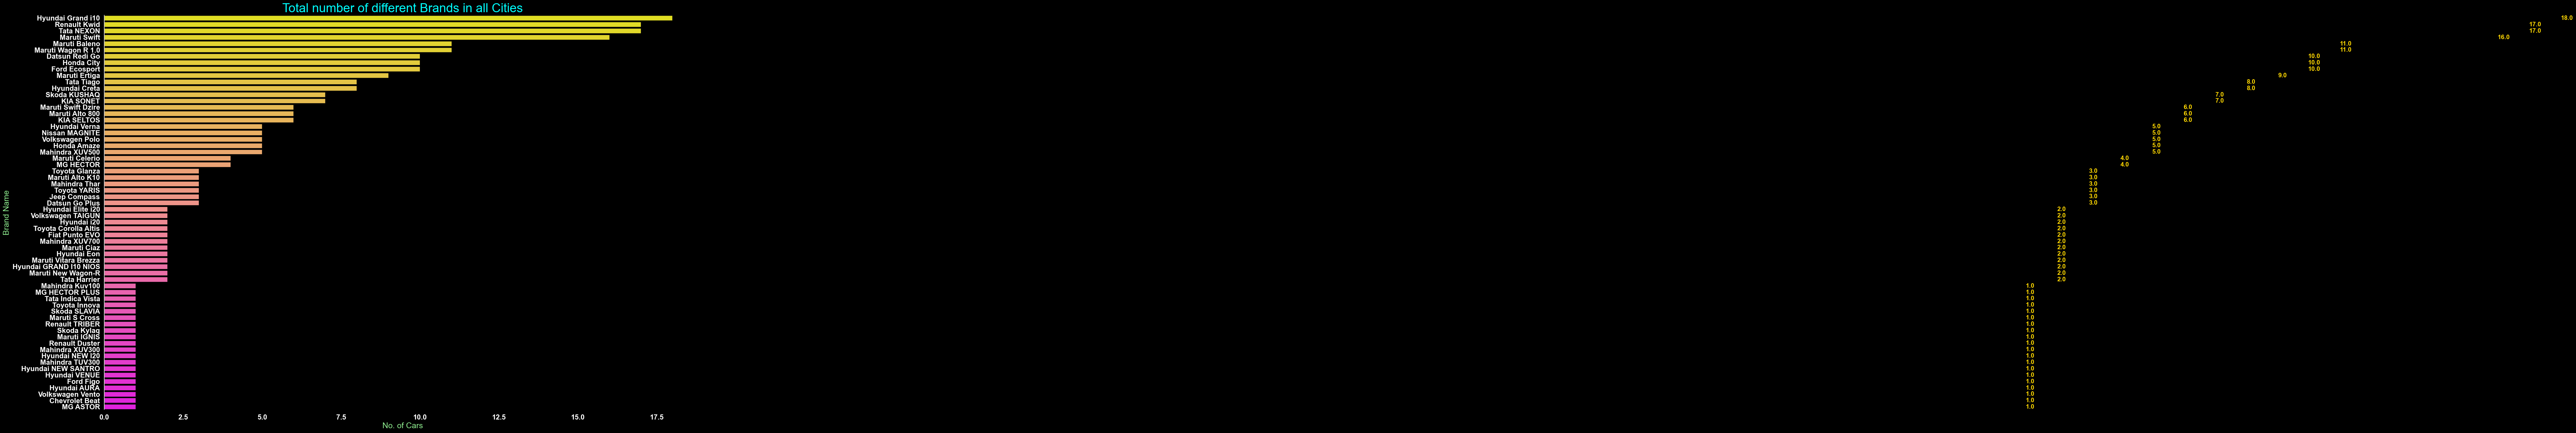

In [18]:
plt.figure(facecolor='black',figsize=(24,16))
sns.set(rc={'figure.figsize':(22,14)})
a = sns.barplot(y ='name',x='count',data=brand_count,palette='spring_r',edgecolor='black')
plt.xticks(rotation=0,fontsize=16,fontweight='bold',color='white')
plt.yticks(fontsize=16,fontweight='bold',color='white')
for p in a.patches:
    width = p.get_width()
    plt.text(60+p.get_width(),p.get_y()+0.55*p.get_height(),'{:1.1f}'.format(width),ha='center',
             va='center',fontsize=14,color='gold',fontweight='bold')
a.set_xlabel("No. of Cars", fontsize = 18,color='lightgreen')
a.set_ylabel("Brand Name", fontsize =18, color='lightgreen')
plt.title("Total number of different Brands in all Cities",fontsize=28,color='cyan')
a.set_facecolor('black')
a.spines['left'].set_color('white')
a.spines['top'].set_color('black')
a.spines['bottom'].set_color('black')
a.spines['right'].set_color('black')
plt.grid(False)

##  2) Average Price of all the brands

In [19]:
brands =df.groupby(by=['name'])

In [21]:
brands.head(10)

,year,name,variant,price,emi,driven_km,fuel,transmission,registration,location,city
0,2023,Nissan MAGNITE,XL,517000.0,9135.0,41774,Petrol,Manual,TS-36,"Kompally, Hyderabad",Hyderabad
1,2022,Maruti Swift,VXI,519000.0,9156.0,40355,Petrol,Manual,TS-15,"Upperpally, Attapur, Hyderabad",Hyderabad
2,2020,Renault Kwid,CLIMBER 1.0 (O),282000.0,4982.0,66791,Petrol,Manual,TS-15,"Kompally, Hyderabad",Hyderabad
3,2023,Maruti Swift,ZXI,593000.0,10470.0,62871,Petrol,Manual,TS-07,"Upperpally, Attapur, Hyderabad",Hyderabad
4,2019,KIA SELTOS,HTK 1.5 PETROL,661000.0,11665.0,70038,Petrol,Manual,TS-10,"Upperpally, Attapur, Hyderabad",Hyderabad
...,...,...,...,...,...,...,...,...,...,...,...
262,2018,Hyundai Eon,ERA +,290000.0,5119.0,50166,Petrol,Manual,TN-09,Sholinganallur,Chennai
267,2016,Datsun Redi Go,S,203000.0,4516.0,72632,Petrol,Manual,TN-01,Sholinganallur,Chennai
269,2021,KIA SONET,HTX 1.0 IMT,650000.0,11467.0,87623,Petrol,Manual,TN-13,Sholinganallur,Chennai
270,2021,Skoda KUSHAQ,STYLE 1.0L TSI MT,788000.0,13913.0,79188,Petrol,Manual,TN-05,"Nexus Vijaya Mall, Vadapalani",Chennai


In [22]:
avg_price = df.groupby(by=['name'])['price'].mean().sort_values(ascending=False).reset_index().rename(
    columns={'price':'Avg Price'})
avg_price['Avg Price'] = avg_price['Avg Price'].astype(int)

C:\Users\DELL\AppData\Local\Temp\ipykernel_18404\508451916.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  a = sns.barplot(y ='name',x='Avg Price',data=avg_price,palette='RdBu_r',edgecolor='none')


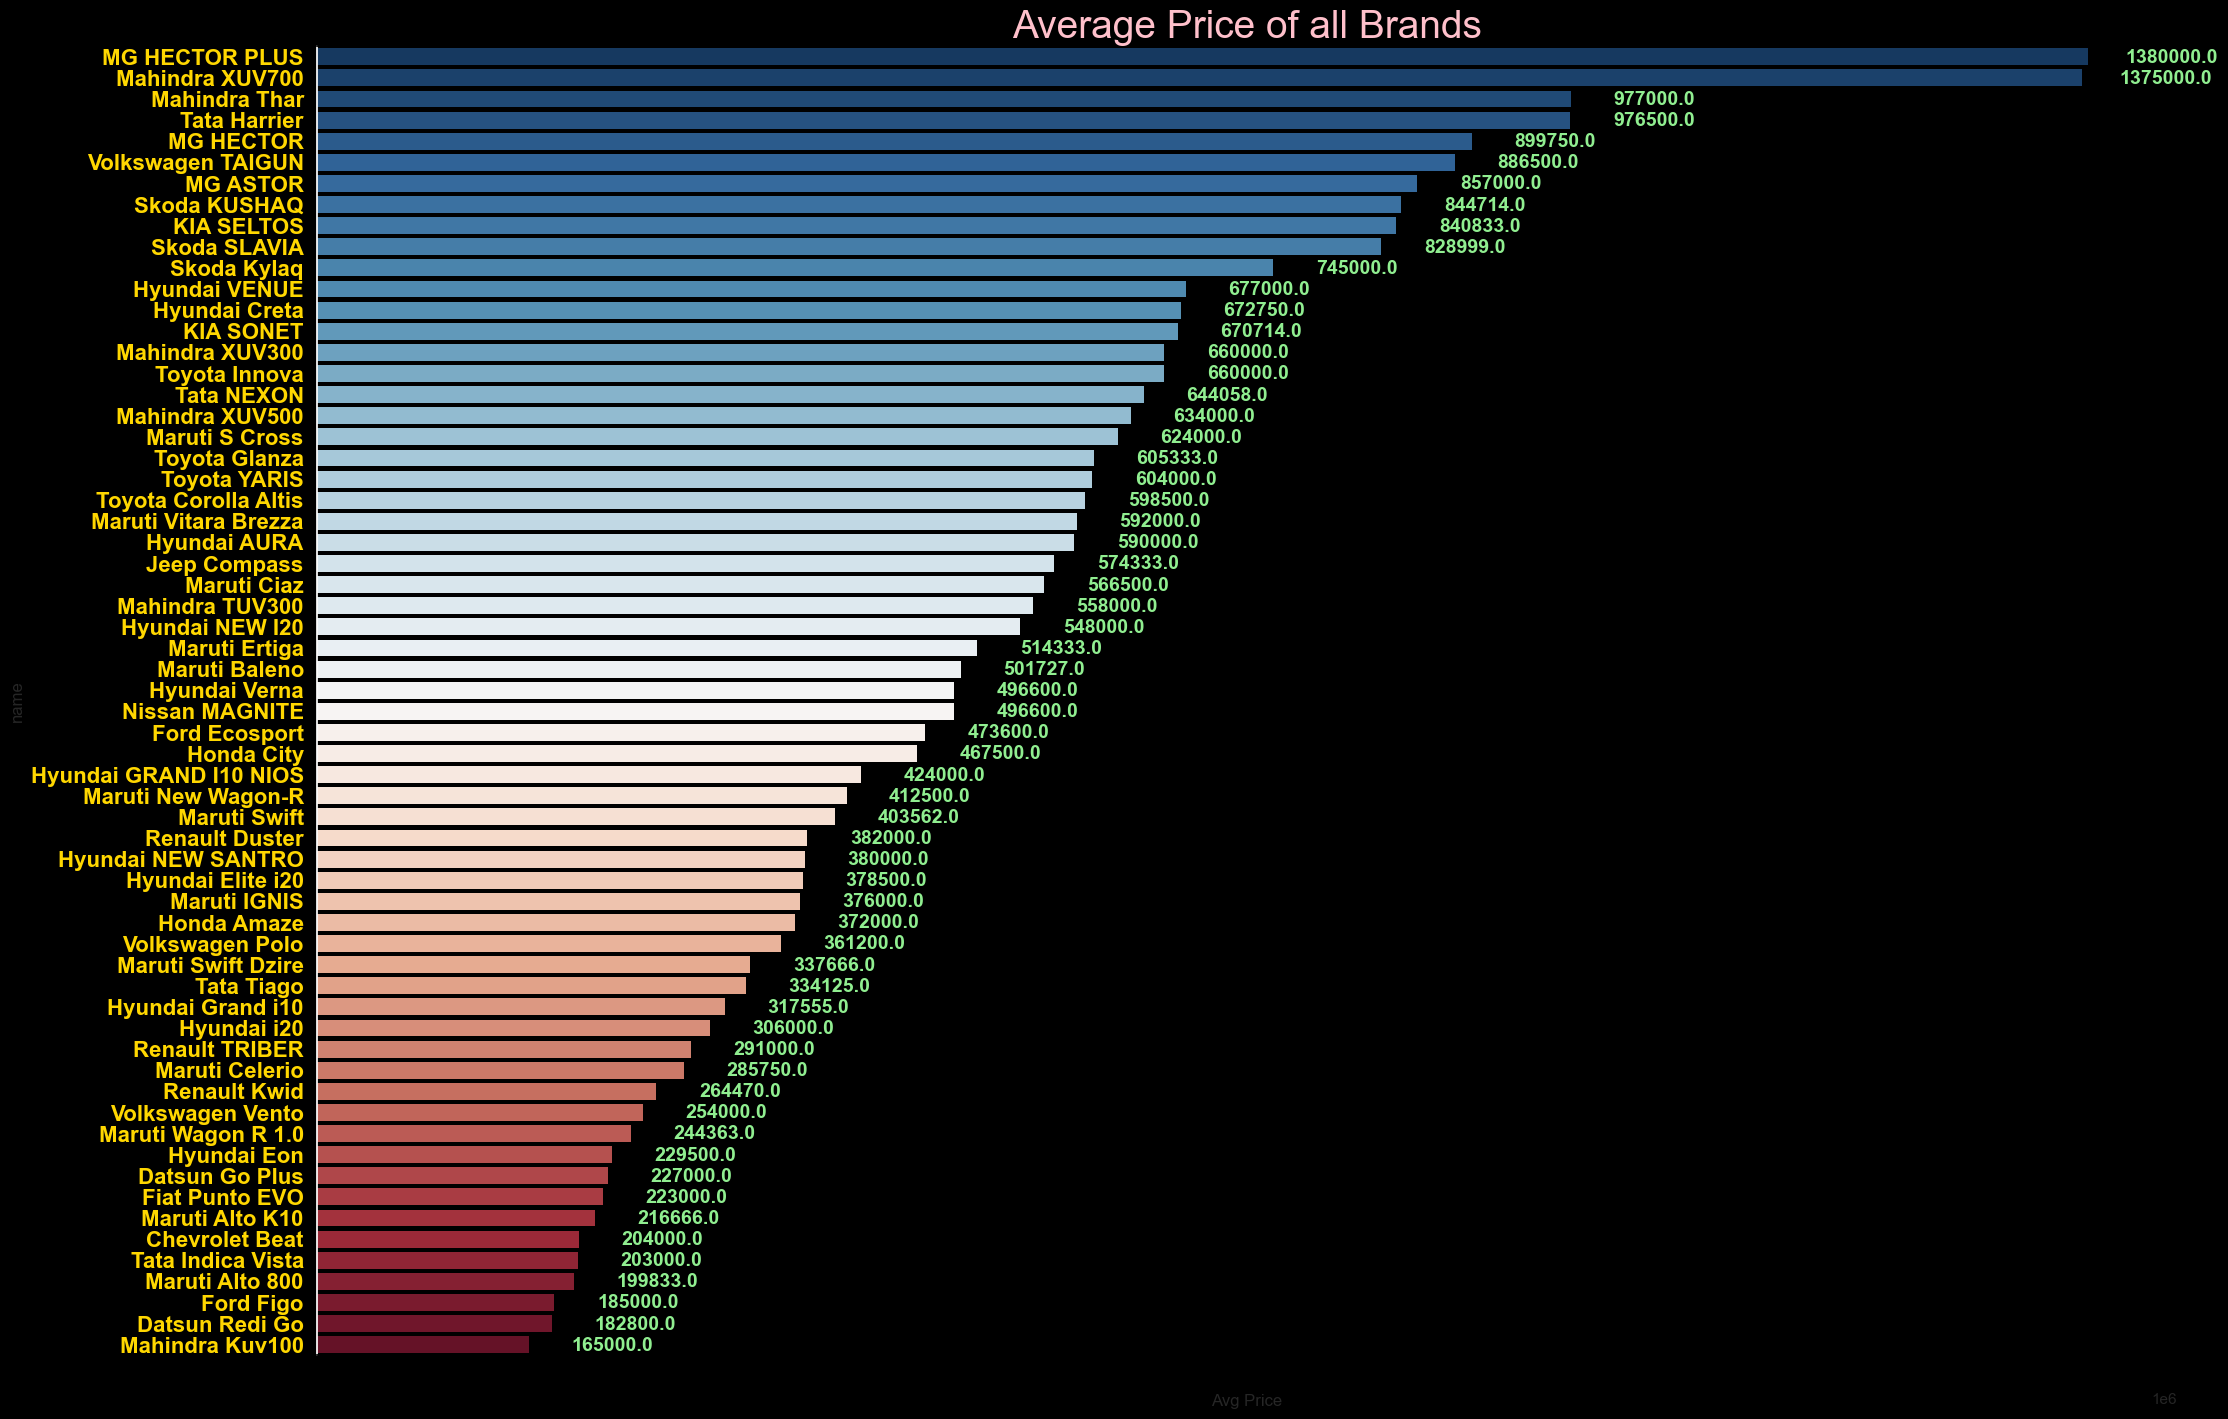

In [23]:
plt.figure(facecolor='black',figsize=(24,17))
sns.set(rc={'figure.figsize':(22,16)})
a = sns.barplot(y ='name',x='Avg Price',data=avg_price,palette='RdBu_r',edgecolor='none')
plt.xticks(rotation=0,fontsize=16,fontweight='bold',color='black')
plt.yticks(fontsize=16,fontweight='bold',color='gold')
for p in a.patches:
    width = p.get_width()
    plt.text(65000+p.get_width(),p.get_y()+0.55*p.get_height(),'{:1.1f}'.format(width),ha='center',
             va='center',fontsize=14,fontweight='bold',color='lightgreen')
plt.title("Average Price of all Brands",fontsize=28,color='pink')
a.set_facecolor('black')
a.spines['left'].set_color('white')
a.spines['top'].set_color('black')
a.spines['bottom'].set_color('black')
a.spines['right'].set_color('black')
plt.grid(False)

## 3) Total no. of different Car Brands in Hyderabad

In [31]:
hyd_city = df.loc[(df['city'] == 'Chennai')]
hyd_brands = hyd_city['name'].value_counts().sort_values(ascending = False).reset_index()

In [28]:
hyd_brands.head()

,name,count
0,Tata NEXON,12
1,Maruti Baleno,8
2,Hyundai Grand i10,8
3,Maruti Swift,8
4,Ford Ecosport,6


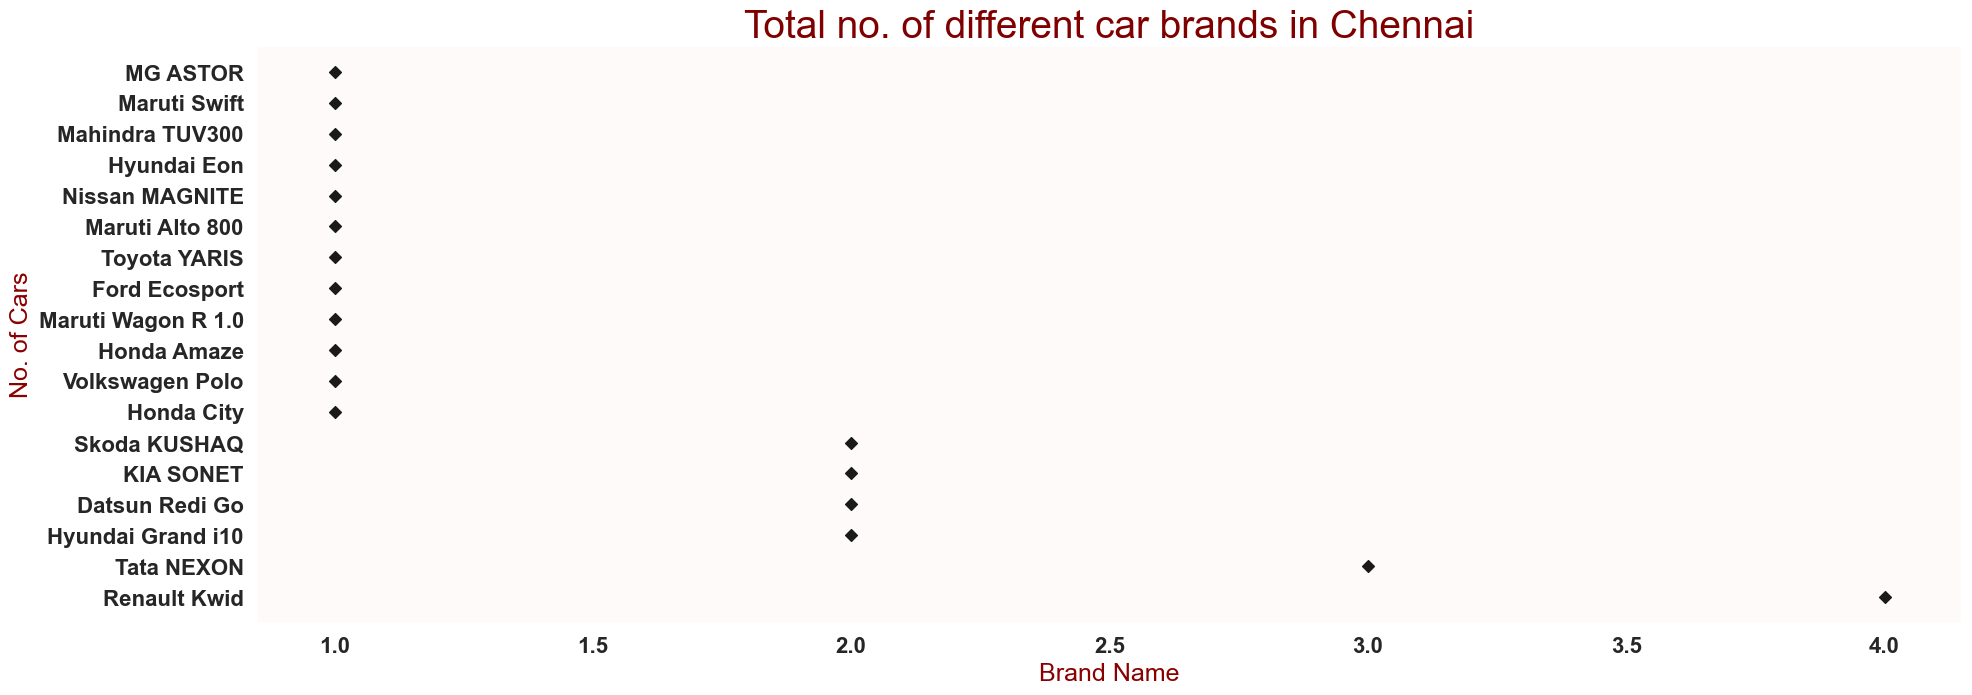

In [33]:
sns.set(rc={'figure.figsize':(22,7.5)})
fig, ax = plt.subplots()
ax.set_facecolor('snow')
plt.scatter('count','name',data=hyd_brands,color='k',marker='D')
plt.xticks(rotation=0,fontsize=16,fontweight='bold')
plt.yticks(fontsize=16,fontweight='bold')

plt.title("Total no. of different car brands in Chennai",fontsize=28,color='maroon')
plt.xlabel("Brand Name", fontsize = 18,color='darkred')
plt.ylabel("No. of Cars", fontsize =18, color='darkred')
plt.grid(False)

## 4) Total no. of different Car Brands in Delhi

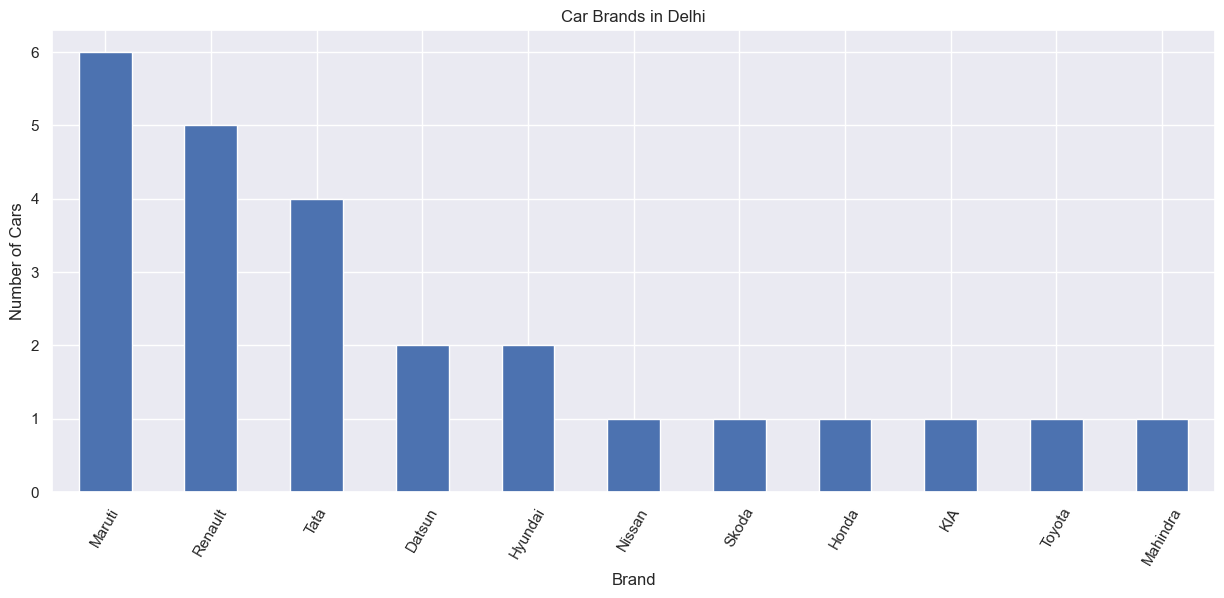

In [23]:
df.loc[df['city'].eq('Delhi'), 'name'].str.split().str[0].value_counts().plot(
    kind='bar', figsize=(15, 6), title='Car Brands in Delhi'
)

plt.xlabel('Brand')
plt.ylabel('Number of Cars')
plt.xticks(rotation=60)
plt.show()

In [38]:
mumbai_brands = (
    df.loc[df['city'].eq('Mumbai'), 'name']
      .str.split().str[0]
      .value_counts()
      .rename_axis('Brand')
      .reset_index(name='Count')
)

In [39]:
mumbai_brands.head()

,Brand,Count
0,Maruti,22
1,Hyundai,17
2,Honda,7
3,Renault,6
4,Tata,6


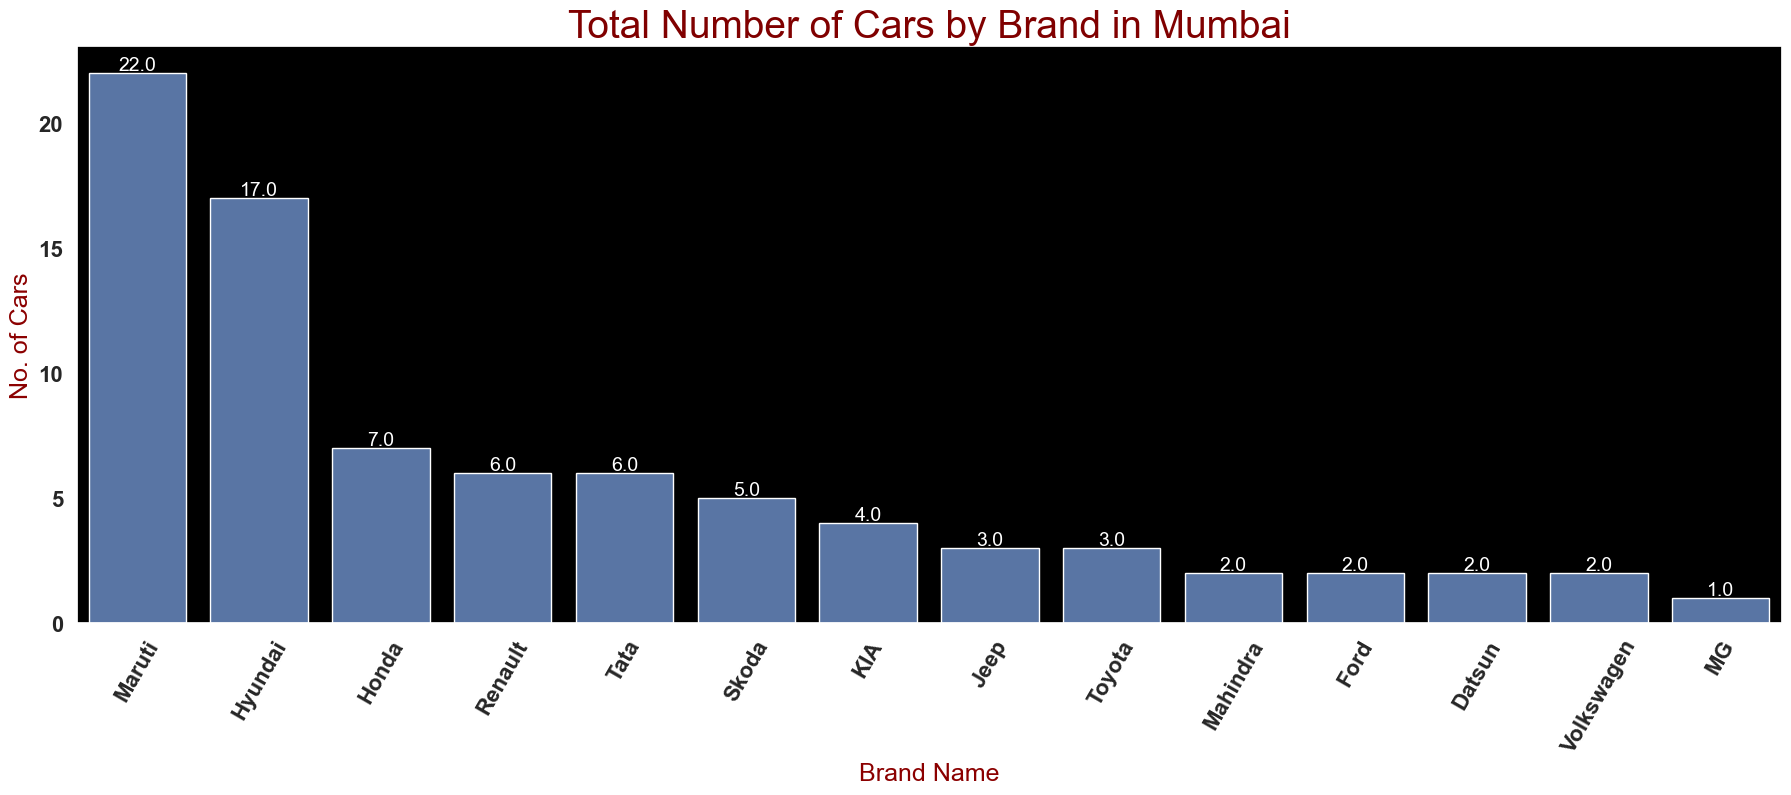

In [ ]:
sns.set(rc={'figure.figsize': (22, 7.5)})

ax = sns.barplot(
    x='Brand',
    y='Count',
    data=mumbai_brands
)

plt.xticks(rotation=60, fontsize=16, fontweight='bold')
plt.yticks(fontsize=16, fontweight='bold')

# Add values on top of bars
for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.1f}',
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center',
        va='center',
        xytext=(0, 6),
        textcoords='offset points',
        fontsize=14,
        color='white'
    )

ax.set_xlabel('Brand Name', fontsize=18, color='darkred')
ax.set_ylabel('No. of Cars', fontsize=18, color='darkred')

plt.title(
    'Total Number of Cars by Brand in Mumbai',
    fontsize=28,
    color='maroon'
)

ax.set_facecolor('black')
plt.grid(False)
plt.show()

In [43]:
bangalore_brands = (
    df.loc[df['city'].eq('Bangalore'), 'name']
      .str.split().str[0]
      .value_counts()
      .rename_axis('Brand')
      .reset_index(name='Count')
)

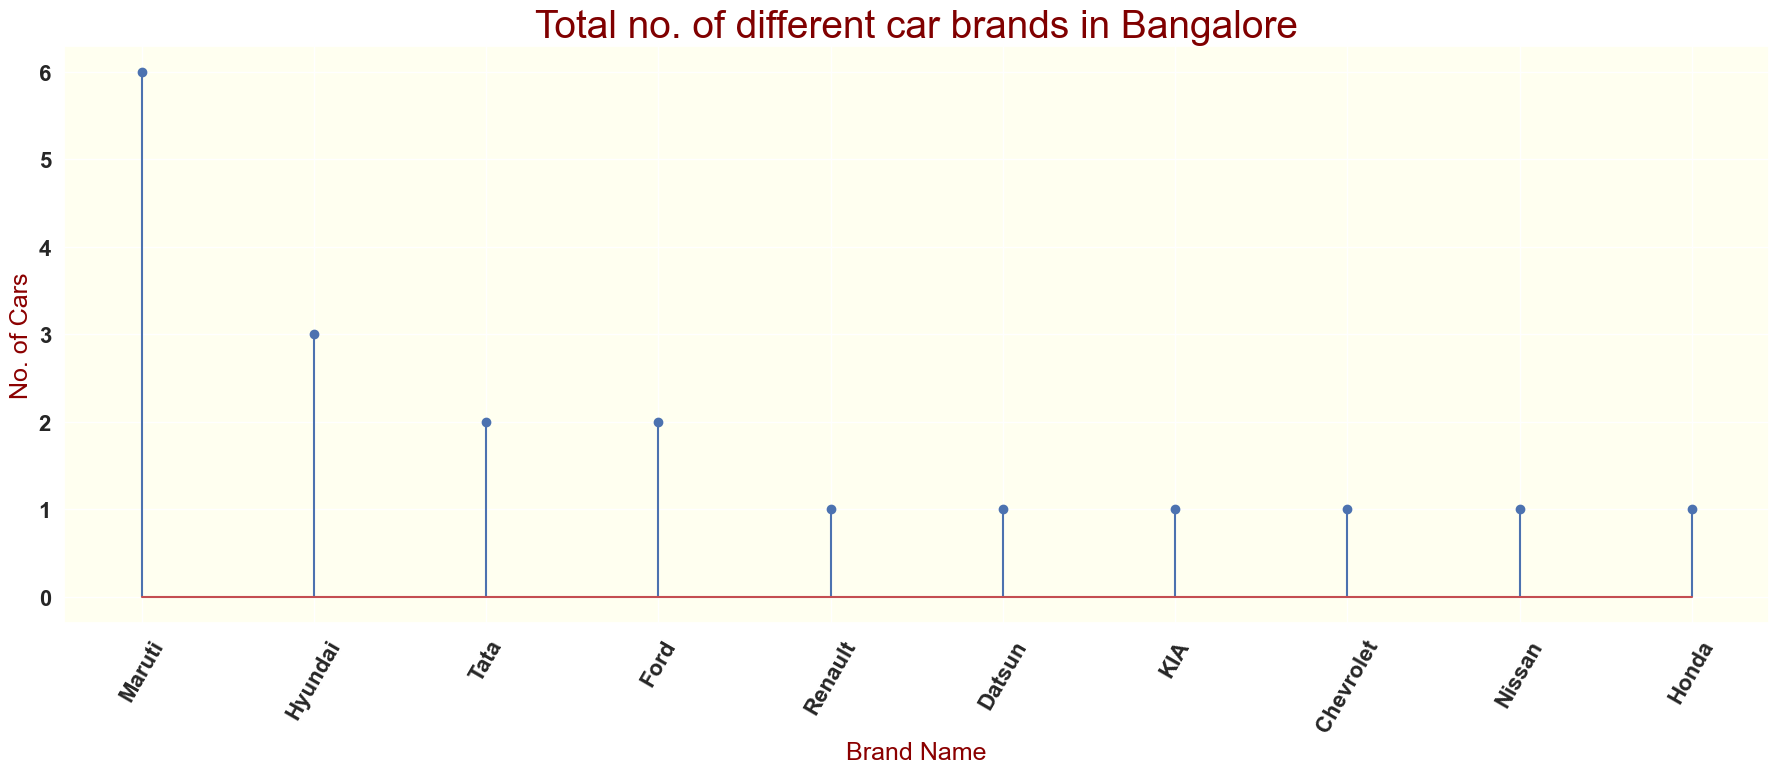

In [45]:
sns.set(rc={'figure.figsize':(22,7.5)})
fig, ax = plt.subplots()
ax.set_facecolor('ivory')
plt.stem('Brand','Count',data=bangalore_brands)
plt.xticks(rotation=60,fontsize=16,fontweight='bold')
plt.yticks(fontsize=16,fontweight='bold')
plt.title("Total no. of different car brands in Bangalore",fontsize=28,color='maroon')
plt.xlabel("Brand Name", fontsize = 18,color='darkred')
plt.ylabel("No. of Cars", fontsize =18, color='darkred')
plt.show()

## 5) Total no. of different Car Brands in Chennai

In [47]:
chennai_brands = (
    df.loc[df['city'].eq('Chennai'), 'name']
      .str.split().str[0]
      .value_counts()
      .rename_axis('Brand')
      .reset_index(name='Count')
)

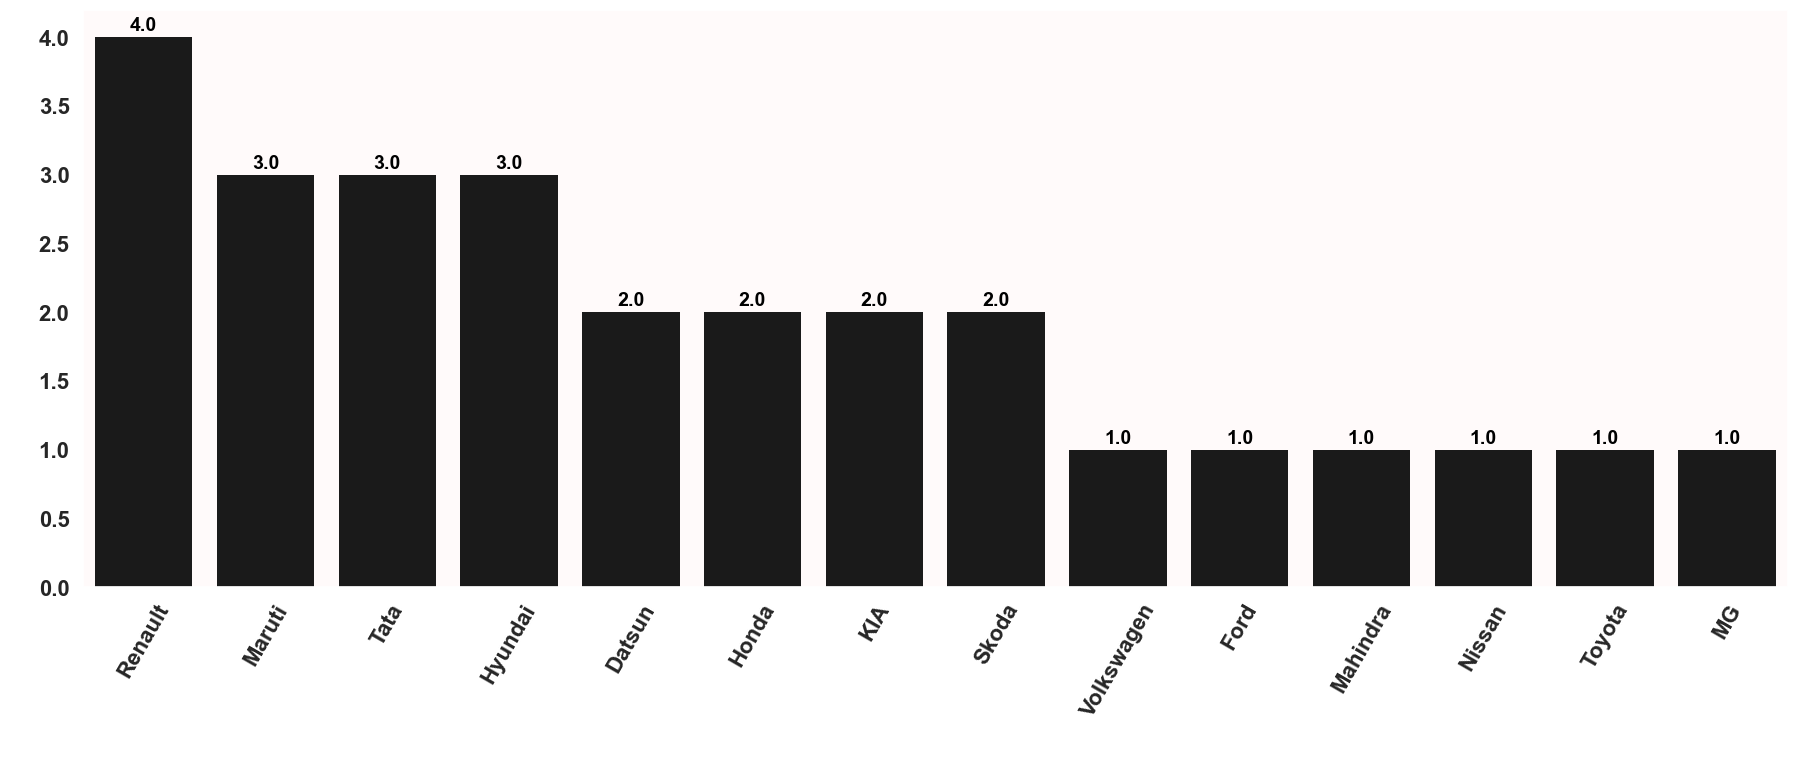

In [48]:
sns.set(rc={'figure.figsize':(22,7.5)})
a = sns.barplot(x ='Brand',y='Count',data=chennai_brands,hatch=('*'),color='k',edgecolor='none')
plt.xticks(rotation=60,fontsize=16,fontweight='bold')
plt.yticks(fontsize=16,fontweight='bold')
for p in a.patches:
    a.annotate(format(p.get_height(),'.1f'),(p.get_x()+p.get_width()/2.,p.get_height()),ha='center',
              va='center',xytext=(0,8),textcoords='offset points',fontsize=14,color='black',fontweight='bold')
a.set_xlabel("Brand Name", fontsize = 18,color='white')
a.set_ylabel("No. of Cars", fontsize =18, color='white')
#plt.title("Total no. of different car brands in Chennai",fontsize=28,color='maroon')
a.set_facecolor('snow')
plt.grid(False)

## 6) Number of Cars based on Fuel type in all cities

In [50]:
fuel_gear = (
    df['fuel']
    .value_counts()
    .rename_axis('Fuel')
    .reset_index(name='Count')
)

C:\Users\DELL\AppData\Local\Temp\ipykernel_26420\831877359.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  a = sns.barplot(x ='Fuel',y='Count',data=fuel_gear,palette='magma_r')


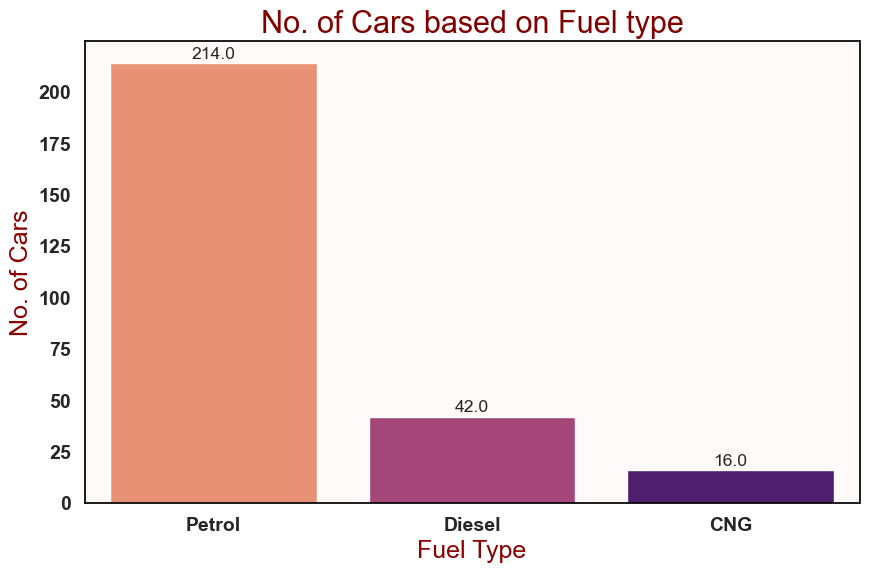

In [52]:
sns.set(rc={'figure.figsize':(10,6)})
a = sns.barplot(x ='Fuel',y='Count',data=fuel_gear,palette='magma_r')
plt.xticks(rotation=0,fontsize=14,fontweight='bold')
plt.yticks(fontsize=14,fontweight='bold')
for p in a.patches:
    a.annotate(format(p.get_height(),'.1f'),(p.get_x()+p.get_width()/2.,p.get_height()),ha='center',
              va='center',xytext=(0,6.5),textcoords='offset points',fontsize=12.6)
a.set_xlabel("Fuel Type", fontsize = 18,color='darkred')
a.set_ylabel("No. of Cars", fontsize =18, color='darkred')
plt.title("No. of Cars based on Fuel type",fontsize=22,color='maroon')
a.set_facecolor('snow')
a.spines['left'].set_color('black')
a.spines['top'].set_color('black')
a.spines['bottom'].set_color('black')
a.spines['right'].set_color('black')
plt.grid(False)

## 7) No. of Cars based on Fuel type in different Cities

In [ ]:
fuel_gear = (
    df['fuel']
    .value_counts()
    .rename_axis('Fuel')
    .reset_index(name='Count')
)

df.loc[df['city'].eq('Chennai'), 'name']

In [55]:
fuel_location = (
    df[['city', 'fuel']]
    .value_counts()
    .rename('Count')
    .reset_index()
    .sort_values(['city', 'Count'])
    .reset_index(drop=True)
)

fuel_location

,city,fuel,Count
0,Bangalore,Petrol,19
1,Chennai,Diesel,1
2,Chennai,Petrol,26
3,Delhi,CNG,1
4,Delhi,Diesel,2
5,Delhi,Petrol,22
6,Hyderabad,CNG,1
7,Hyderabad,Diesel,29
8,Hyderabad,Petrol,89
9,Mumbai,Diesel,10


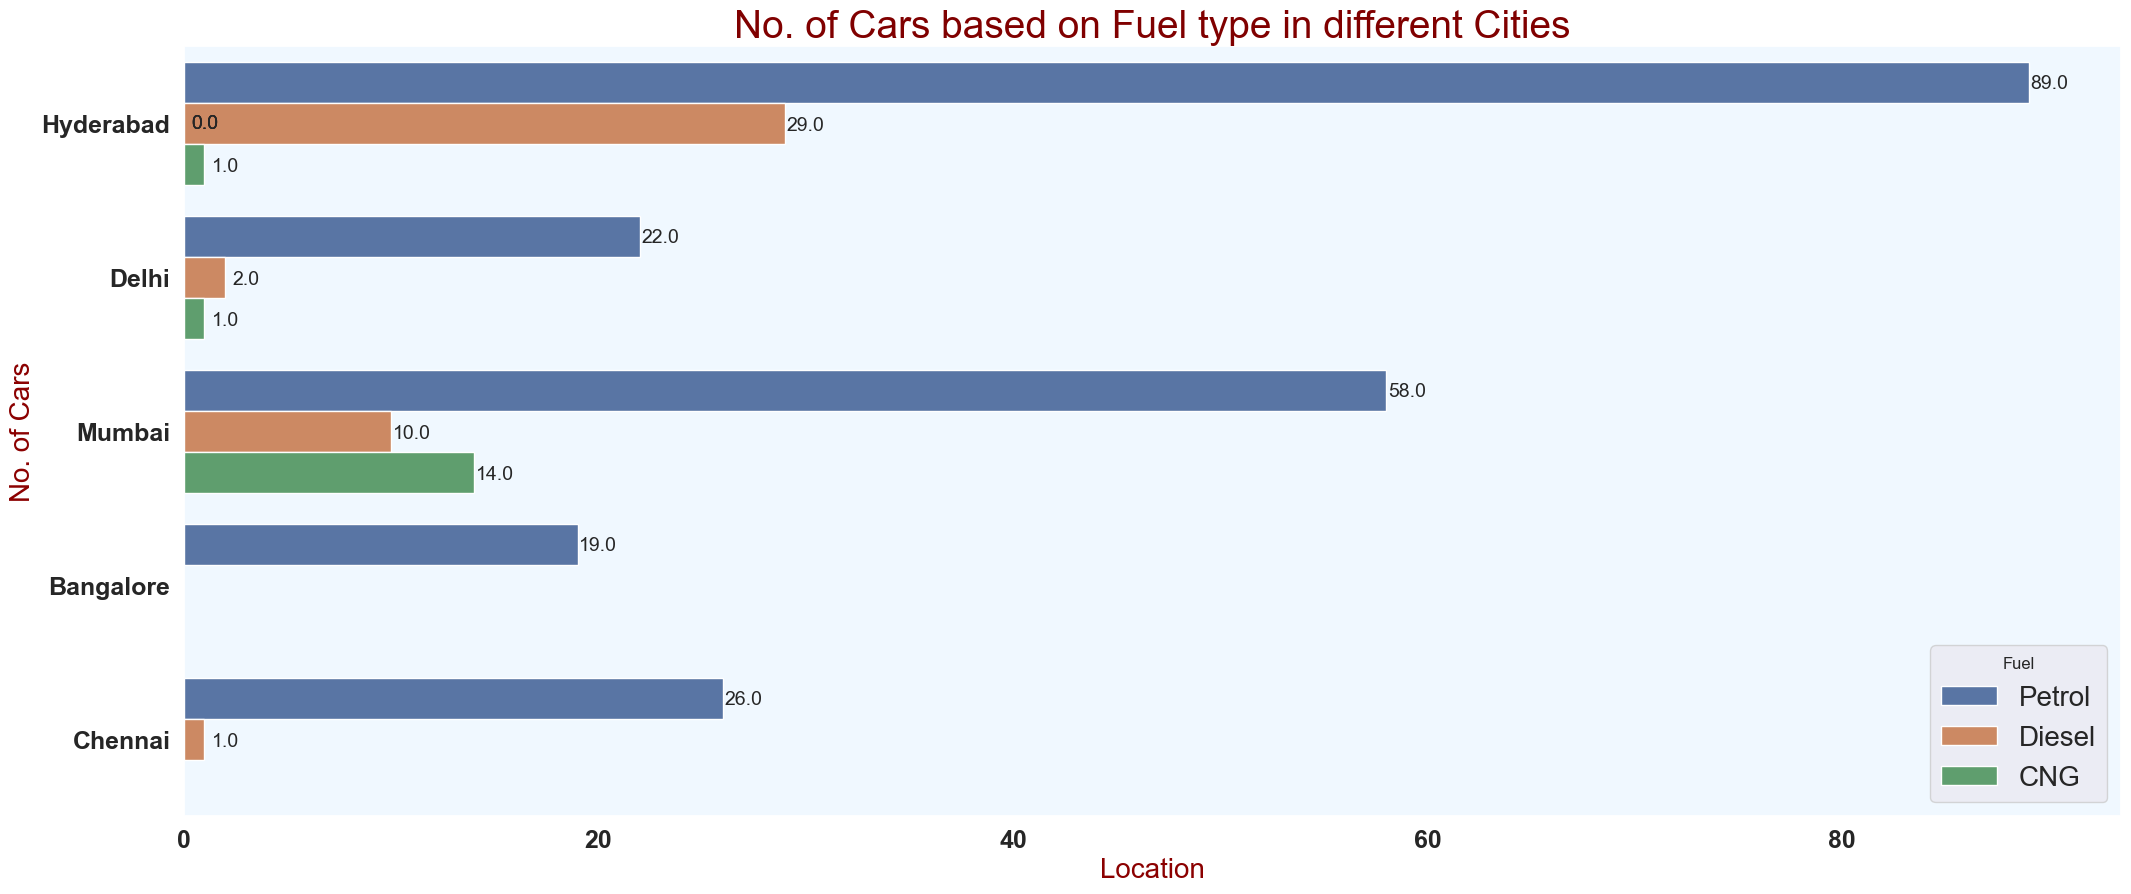

In [57]:
sns.set(rc={'figure.figsize':(25,10)})
a = sns.countplot(y = 'city',hue='fuel',data=df)
plt.xticks(rotation=0,fontsize=18,fontweight='bold')
plt.yticks(fontsize=18,fontweight='bold')
for p in a.patches:
    width = p.get_width()
    plt.text(1+p.get_width(),p.get_y()+0.55*p.get_height(),'{:1.1f}'.format(width),ha='center',va='center',fontsize=14)
a.set_xlabel("Location", fontsize = 20,color='darkred')
a.set_ylabel("No. of Cars", fontsize =20, color='darkred')
plt.title("No. of Cars based on Fuel type in different Cities",fontsize=28,color='maroon')
a.set_facecolor('aliceblue')
plt.legend(loc='lower right',title='Fuel',prop={'size': 20})
a.grid(False)

## 8) No. of cars in different Cities based on Model Year

In [72]:
year_cars = (
    df[['city', 'year']]
    .value_counts()
    .rename('Count')
    .reset_index()
    .sort_values(['city', 'Count'])
    .reset_index(drop=True)
)

In [73]:
year_cars.head()

,city,year,Count
0,Bangalore,2016,1
1,Bangalore,2020,1
2,Bangalore,2015,2
3,Bangalore,2018,2
4,Bangalore,2021,2


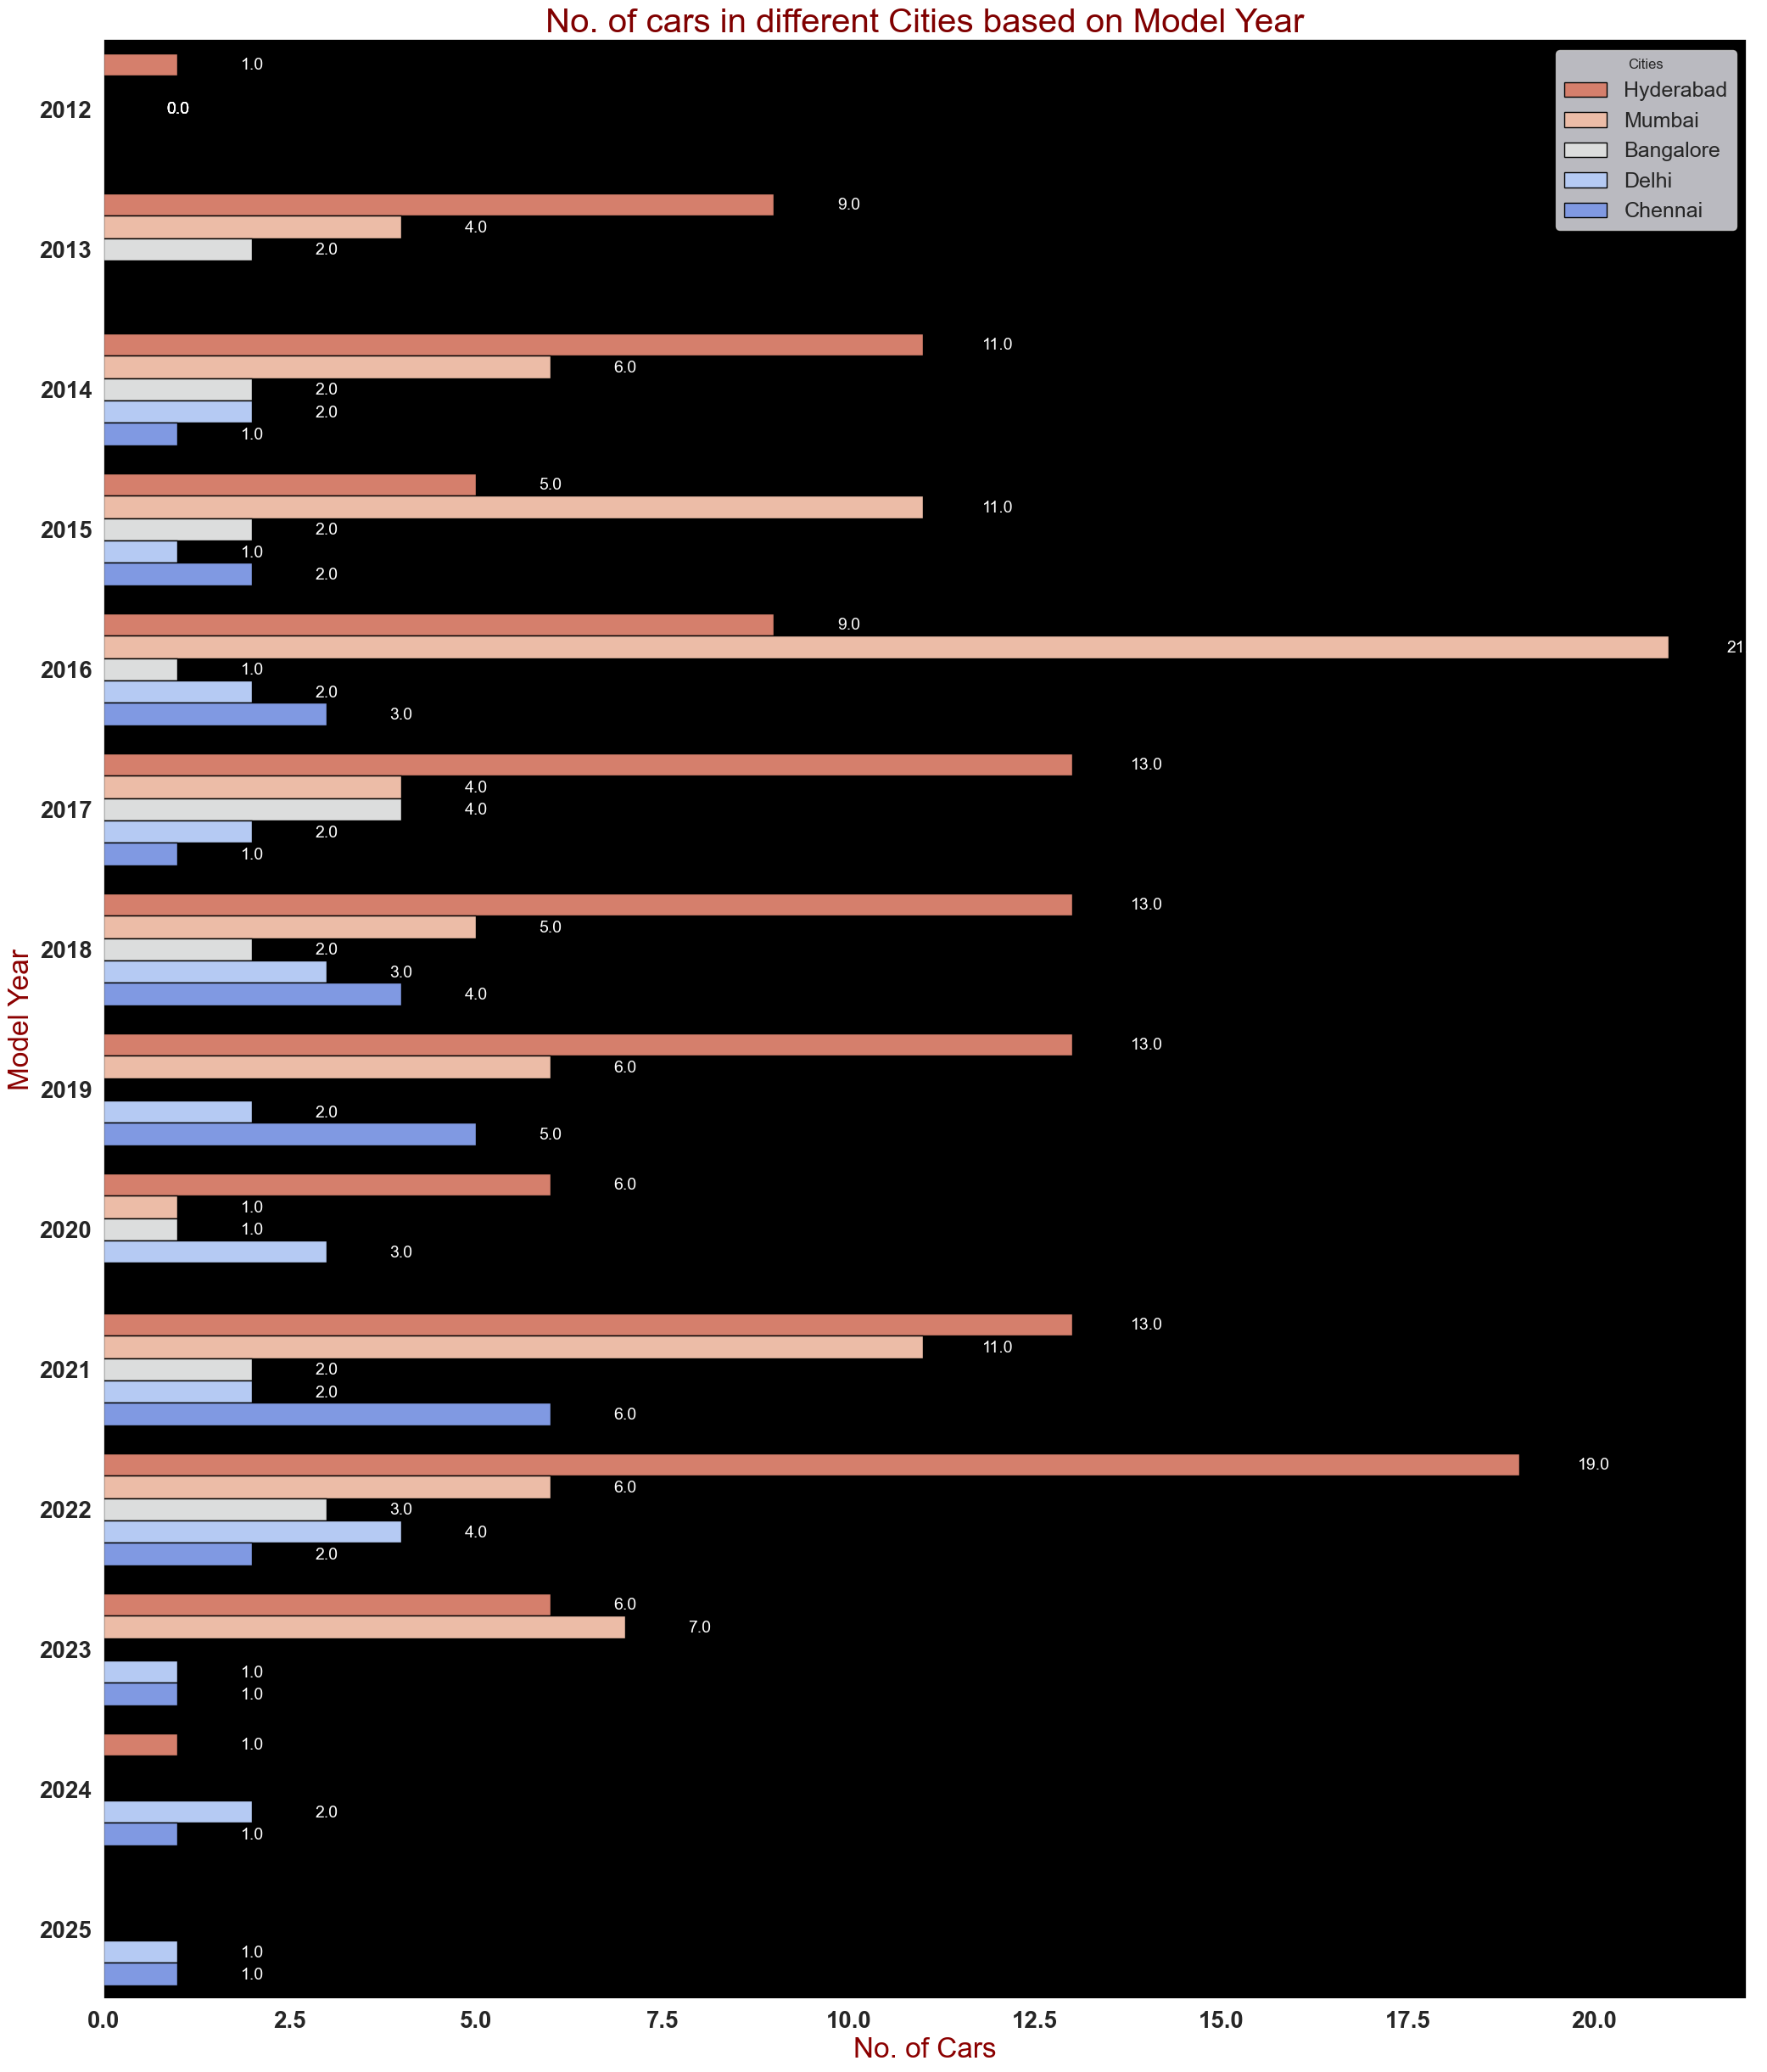

In [62]:
sns.set(rc={'figure.figsize':(25,30)})
a = sns.countplot(y = 'year',hue='city',data=df,edgecolor='black',palette='coolwarm_r')
plt.xticks(rotation=0,fontsize=20,fontweight='bold')
plt.yticks(fontsize=20,fontweight='bold')
for p in a.patches:
    width = p.get_width()
    plt.text(1+p.get_width(),p.get_y()+0.55*p.get_height(),'{:1.1f}'.format(width),ha='center',va='center',fontsize=14,
            color='white')
a.set_ylabel("Model Year", fontsize = 24,color='darkred')
a.set_xlabel("No. of Cars", fontsize =24, color='darkred')
plt.title("No. of cars in different Cities based on Model Year",fontsize=29,color='maroon')
a.set_facecolor('black')
plt.legend(loc='upper right',title='Cities',prop={'size': 18})
a.grid(False)

## 9) No. of Cars in different cities based on Gear

In [70]:
#transmission

transmission_year_cars = (
    df[['city', 'transmission']]
    .value_counts()
    .rename('Count')
    .reset_index()
    .sort_values(['city', 'Count'])
    .reset_index(drop=True)
)

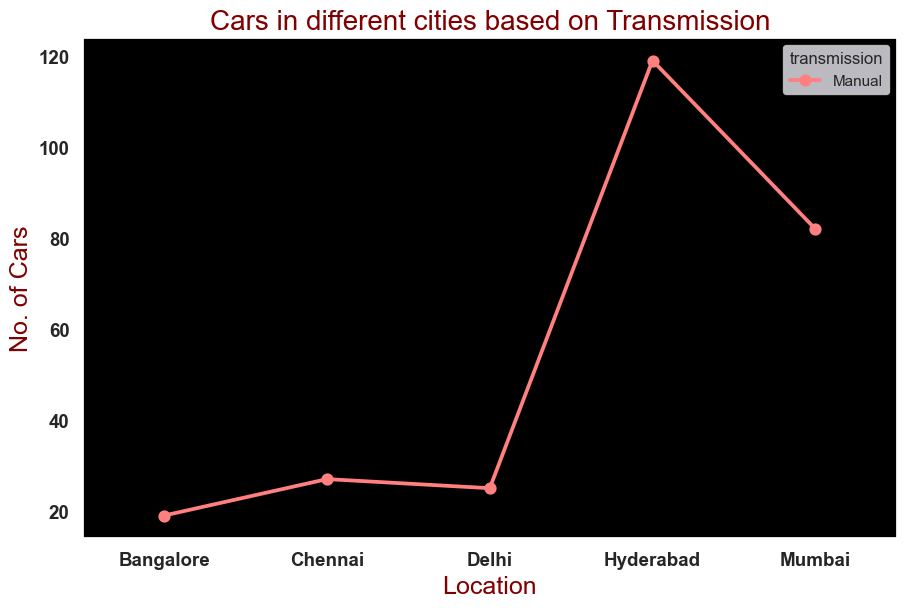

In [71]:
sns.set(rc={'figure.figsize':(10.5,6.5)})
plt.xticks(rotation=0,fontsize=13.5,fontweight='bold')
plt.yticks(fontsize=13.5,fontweight='bold')
a = sns.pointplot(x='city',y='Count',hue='transmission',data=year_cars,palette='spring')
a.set_facecolor('black')
a.set_xlabel("Location", fontsize = 18,color='maroon')
a.set_ylabel("No. of Cars", fontsize =18, color='maroon')
plt.title("Cars in different cities based on Transmission",fontsize=20,color='maroon')
plt.grid(False)

## 10) Average Price, EMI, Driven(Kms) based on Fuel type in Bangalore

In [78]:
models = (
    df.groupby(['city', 'fuel'])[['price', 'year', 'driven_km', 'emi']]
      .mean()
      .astype(int)
      .reset_index()
)

mumbai = models[models['city'] == 'Mumbai']

mumbai

,city,fuel,price,year,driven_km,emi
9,Mumbai,CNG,400285,2017,72978,11706
10,Mumbai,Diesel,692200,2017,88763,16552
11,Mumbai,Petrol,428275,2017,47551,8895


C:\Users\DELL\AppData\Local\Temp\ipykernel_26420\3535679488.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  a = sns.barplot(x='fuel',y='price',data=mumbai,palette='rocket',ax =axes[0])
C:\Users\DELL\AppData\Local\Temp\ipykernel_26420\3535679488.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  b = sns.barplot(x='fuel',y='driven_km',data=mumbai,palette='rocket',ax =axes[1])
C:\Users\DELL\AppData\Local\Temp\ipykernel_26420\3535679488.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  c = sns.barplot(x='fuel',y='emi',data=mumbai,palette='rocket',ax =axes[2])


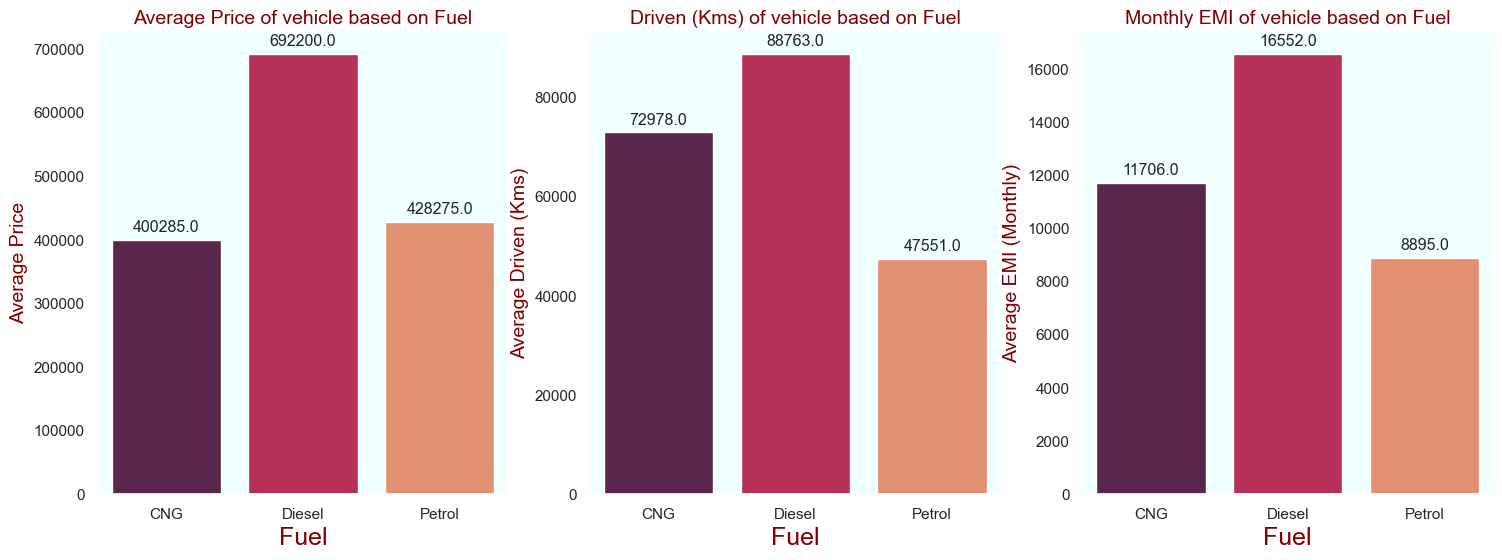

In [80]:
f, axes = plt.subplots(1, 3, figsize=(18,6))
#1st plot
a = sns.barplot(x='fuel',y='price',data=mumbai,palette='rocket',ax =axes[0])
a.set_facecolor('azure')
a.set_xlabel("Fuel", fontsize = 18,color='maroon')
for p in a.patches:
    a.annotate(format(p.get_height()),(p.get_x()+p.get_width()/2.,p.get_height()),ha='center',
               va='center',xytext=(0,9),textcoords='offset points',fontsize=11.5)
a.set_ylabel("Average Price", fontsize =14, color='maroon')
a.set_title("Average Price of vehicle based on Fuel", fontsize =14, color='maroon')
#2nd plot
b = sns.barplot(x='fuel',y='driven_km',data=mumbai,palette='rocket',ax =axes[1])
b.set_facecolor('azure')
b.set_xlabel("Fuel", fontsize = 18,color='maroon')
for p in b.patches:
    b.annotate(format(p.get_height()),(p.get_x()+p.get_width()/2.,p.get_height()),ha='center',
               va='center',xytext=(0,9),textcoords='offset points',fontsize=11.5)
b.set_ylabel("Average Driven (Kms)", fontsize =14, color='maroon')
b.set_title("Driven (Kms) of vehicle based on Fuel", fontsize =14, color='maroon')
#3rd plot
c = sns.barplot(x='fuel',y='emi',data=mumbai,palette='rocket',ax =axes[2])
c.set_facecolor('azure')
c.set_xlabel("Fuel", fontsize = 18,color='maroon')
for p in c.patches:
    c.annotate(format(p.get_height()),(p.get_x()+p.get_width()/2.,p.get_height()),ha='center',
               va='center',xytext=(0,9),textcoords='offset points',fontsize=11.5)
c.set_ylabel("Average EMI (Monthly)", fontsize =14, color='maroon')
c.set_title("Monthly EMI of vehicle based on Fuel", fontsize =14, color='maroon')
a.grid(False)
b.grid(False)
c.grid(False)

## 11) Average Price, EMI, Driven(Kms) based on Fuel type in Chennai

In [81]:
models = (
    df.groupby(['city', 'fuel'])[['price', 'year', 'driven_km', 'emi']]
      .mean()
      .astype(int)
      .reset_index()
)

Chennai = models[models['city'] == 'Chennai']

Chennai

,city,fuel,price,year,driven_km,emi
1,Chennai,Diesel,558000,2016,75274,14707
2,Chennai,Petrol,509769,2019,52752,9542


C:\Users\DELL\AppData\Local\Temp\ipykernel_26420\2712272244.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  a = sns.barplot(x='fuel',y='price',data=Chennai,palette='Blues_d',ax =axes[0])
C:\Users\DELL\AppData\Local\Temp\ipykernel_26420\2712272244.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  b = sns.barplot(x='fuel',y='driven_km',data=Chennai,palette='Blues_d',ax =axes[1])
C:\Users\DELL\AppData\Local\Temp\ipykernel_26420\2712272244.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  c = sns.barplot(x='fuel',y='emi',data=Chennai,palette='Blues_d',ax =axes[2])


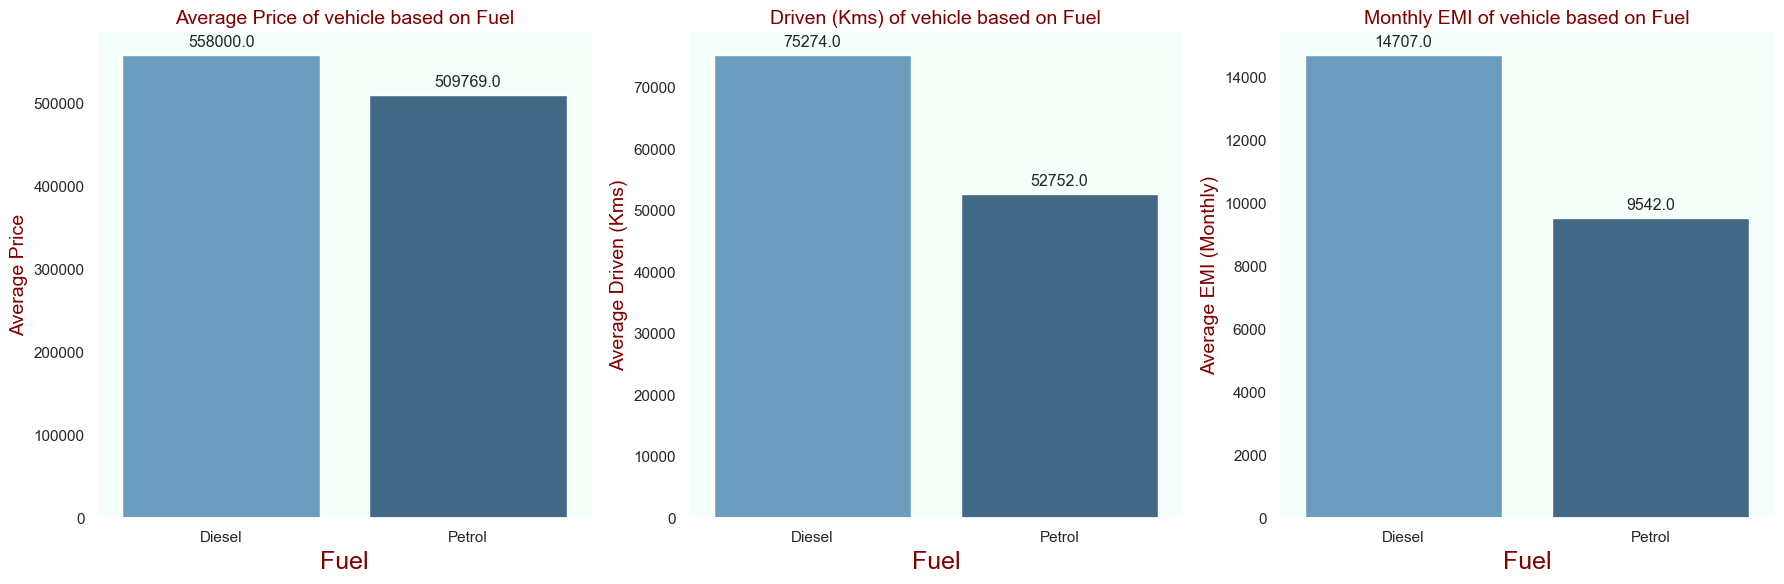

In [83]:
f, axes = plt.subplots(1, 3, figsize=(18,6))
#1st plot
a = sns.barplot(x='fuel',y='price',data=Chennai,palette='Blues_d',ax =axes[0])
a.set_facecolor('mintcream')
a.set_xlabel("Fuel", fontsize = 18,color='maroon')
for p in a.patches:
    a.annotate(format(p.get_height()),(p.get_x()+p.get_width()/2.,p.get_height()),ha='center',
               va='center',xytext=(0,9),textcoords='offset points',fontsize=11.5)
a.set_ylabel("Average Price", fontsize =14, color='maroon')
a.set_title("Average Price of vehicle based on Fuel", fontsize =14, color='maroon')
#2nd plot
b = sns.barplot(x='fuel',y='driven_km',data=Chennai,palette='Blues_d',ax =axes[1])
b.set_facecolor('mintcream')
b.set_xlabel("Fuel", fontsize = 18,color='maroon')
for p in b.patches:
    b.annotate(format(p.get_height()),(p.get_x()+p.get_width()/2.,p.get_height()),ha='center',
               va='center',xytext=(0,9),textcoords='offset points',fontsize=11.5)
b.set_ylabel("Average Driven (Kms)", fontsize =14, color='maroon')
b.set_title("Driven (Kms) of vehicle based on Fuel", fontsize =14, color='maroon')
#3rd plot
c = sns.barplot(x='fuel',y='emi',data=Chennai,palette='Blues_d',ax =axes[2])
c.set_facecolor('mintcream')
c.set_xlabel("Fuel", fontsize = 18,color='maroon')
for p in c.patches:
    c.annotate(format(p.get_height()),(p.get_x()+p.get_width()/2.,p.get_height()),ha='center',
               va='center',xytext=(0,9),textcoords='offset points',fontsize=11.5)
c.set_ylabel("Average EMI (Monthly)", fontsize =14, color='maroon')
c.set_title("Monthly EMI of vehicle based on Fuel", fontsize =14, color='maroon')
plt.tight_layout()
a.grid(False)
b.grid(False)
c.grid(False)

## 12) Car with highest & lowest price in Hyderabad

In [86]:
by_models = (
    df.groupby(['city', 'name', 'variant'])[['price', 'year', 'driven_km', 'emi']]
      .median()
      .dropna()
      .astype(int)
      .reset_index()
)

model_M = (
    by_models[by_models["city"] == "Mumbai"]
    .sort_values("price", ascending=False)
)

In [88]:
def max_min(column):
    high = model_M[column].idxmax()
    high_model = pd.DataFrame(model_M.loc[high])
    low = model_M[column].idxmin()
    low_model = pd.DataFrame(model_M.loc[low])
    high_low = pd.concat([high_model,low_model],axis=1)
    return high_low
max_min('price')

,172,150
city,Mumbai,Mumbai
name,Mahindra XUV700,Datsun Redi Go
variant,AX 7 D MT 7 STR,T (O)
price,1651000,129000
year,2022,2016
driven_km,71632,48543
emi,28269,2878


## 13) Car with highest & lowest price in Chennai

In [89]:
model_c = by_models[by_models["city"] == "Chennai"].sort_values("price", ascending=False)

In [90]:
def max_min(column):
    high = model_c[column].idxmax()
    high_model = pd.DataFrame(model_c.loc[high])
    low = model_c[column].idxmin()
    low_model = pd.DataFrame(model_c.loc[low])
    high_low = pd.concat([high_model,low_model],axis=1)
    return high_low
max_min('price')

,26,19
city,Chennai,Chennai
name,MG ASTOR,Datsun Redi Go
variant,Sprint 1.5 MT (Ivory),S
price,857000,230500
year,2024,2017
driven_km,11044,65482
emi,14670,4535


## 14) Comparision of car brand count in different Cities

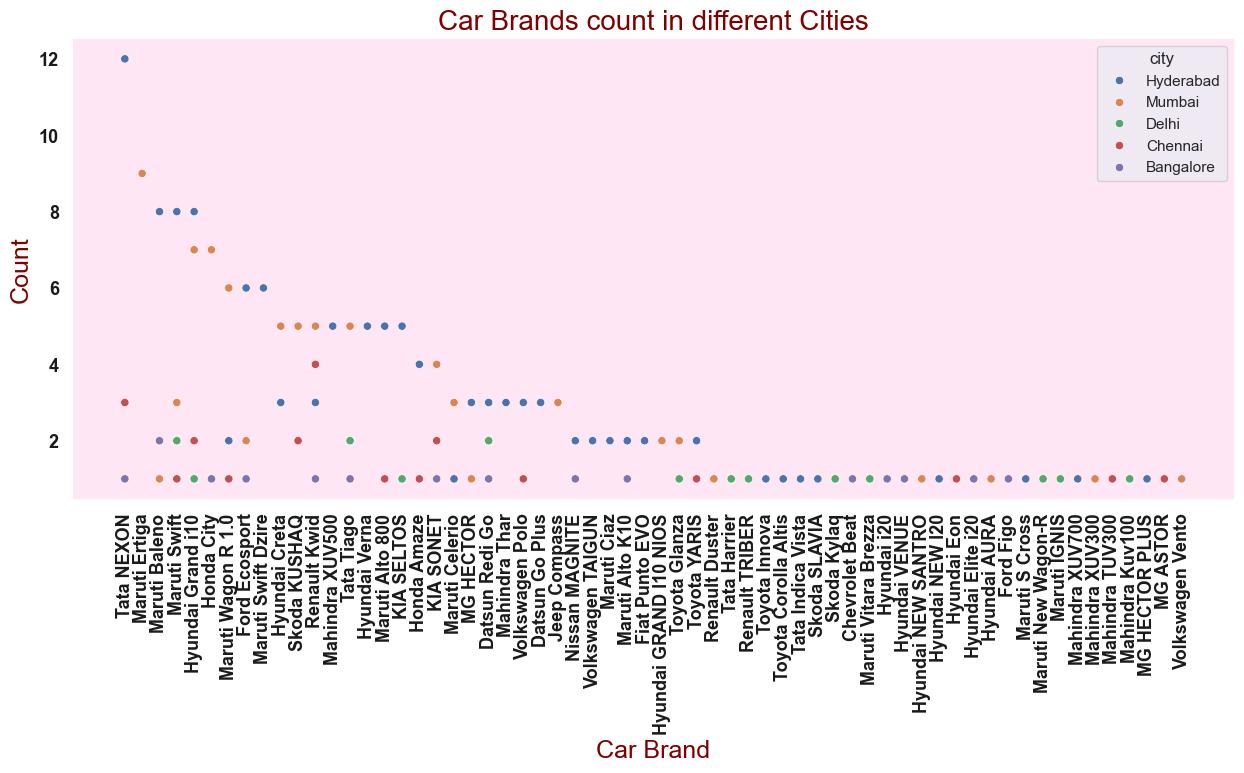

In [91]:
by_model = (
    df[['name', 'city']]
    .value_counts()
    .reset_index(name='Count')
)
sns.set(rc={'figure.figsize':(15,6)})
a = sns.scatterplot(y='Count',x='name',hue='city',data=by_model)

a.set_ylabel("Count", fontsize = 18,color='maroon')
a.set_xlabel("Car Brand", fontsize =18, color='maroon')
a.set_title("Car Brands count in different Cities", fontsize =20, color='maroon')
a.set_facecolor('#FFE6F5')
plt.xticks(rotation = 90,fontsize=13,color='k',fontweight='bold')
plt.yticks(fontsize=13,color='k',fontweight='bold')
a.grid(False)
plt.show()

## 15) Car Brand vs Average Price

In [93]:
df['Brand'] = df['name'].str.split().str[0]

C:\Users\DELL\AppData\Local\Temp\ipykernel_26420\324853720.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  a = sns.boxplot(x='Brand',y='price',data=df,palette='bright')


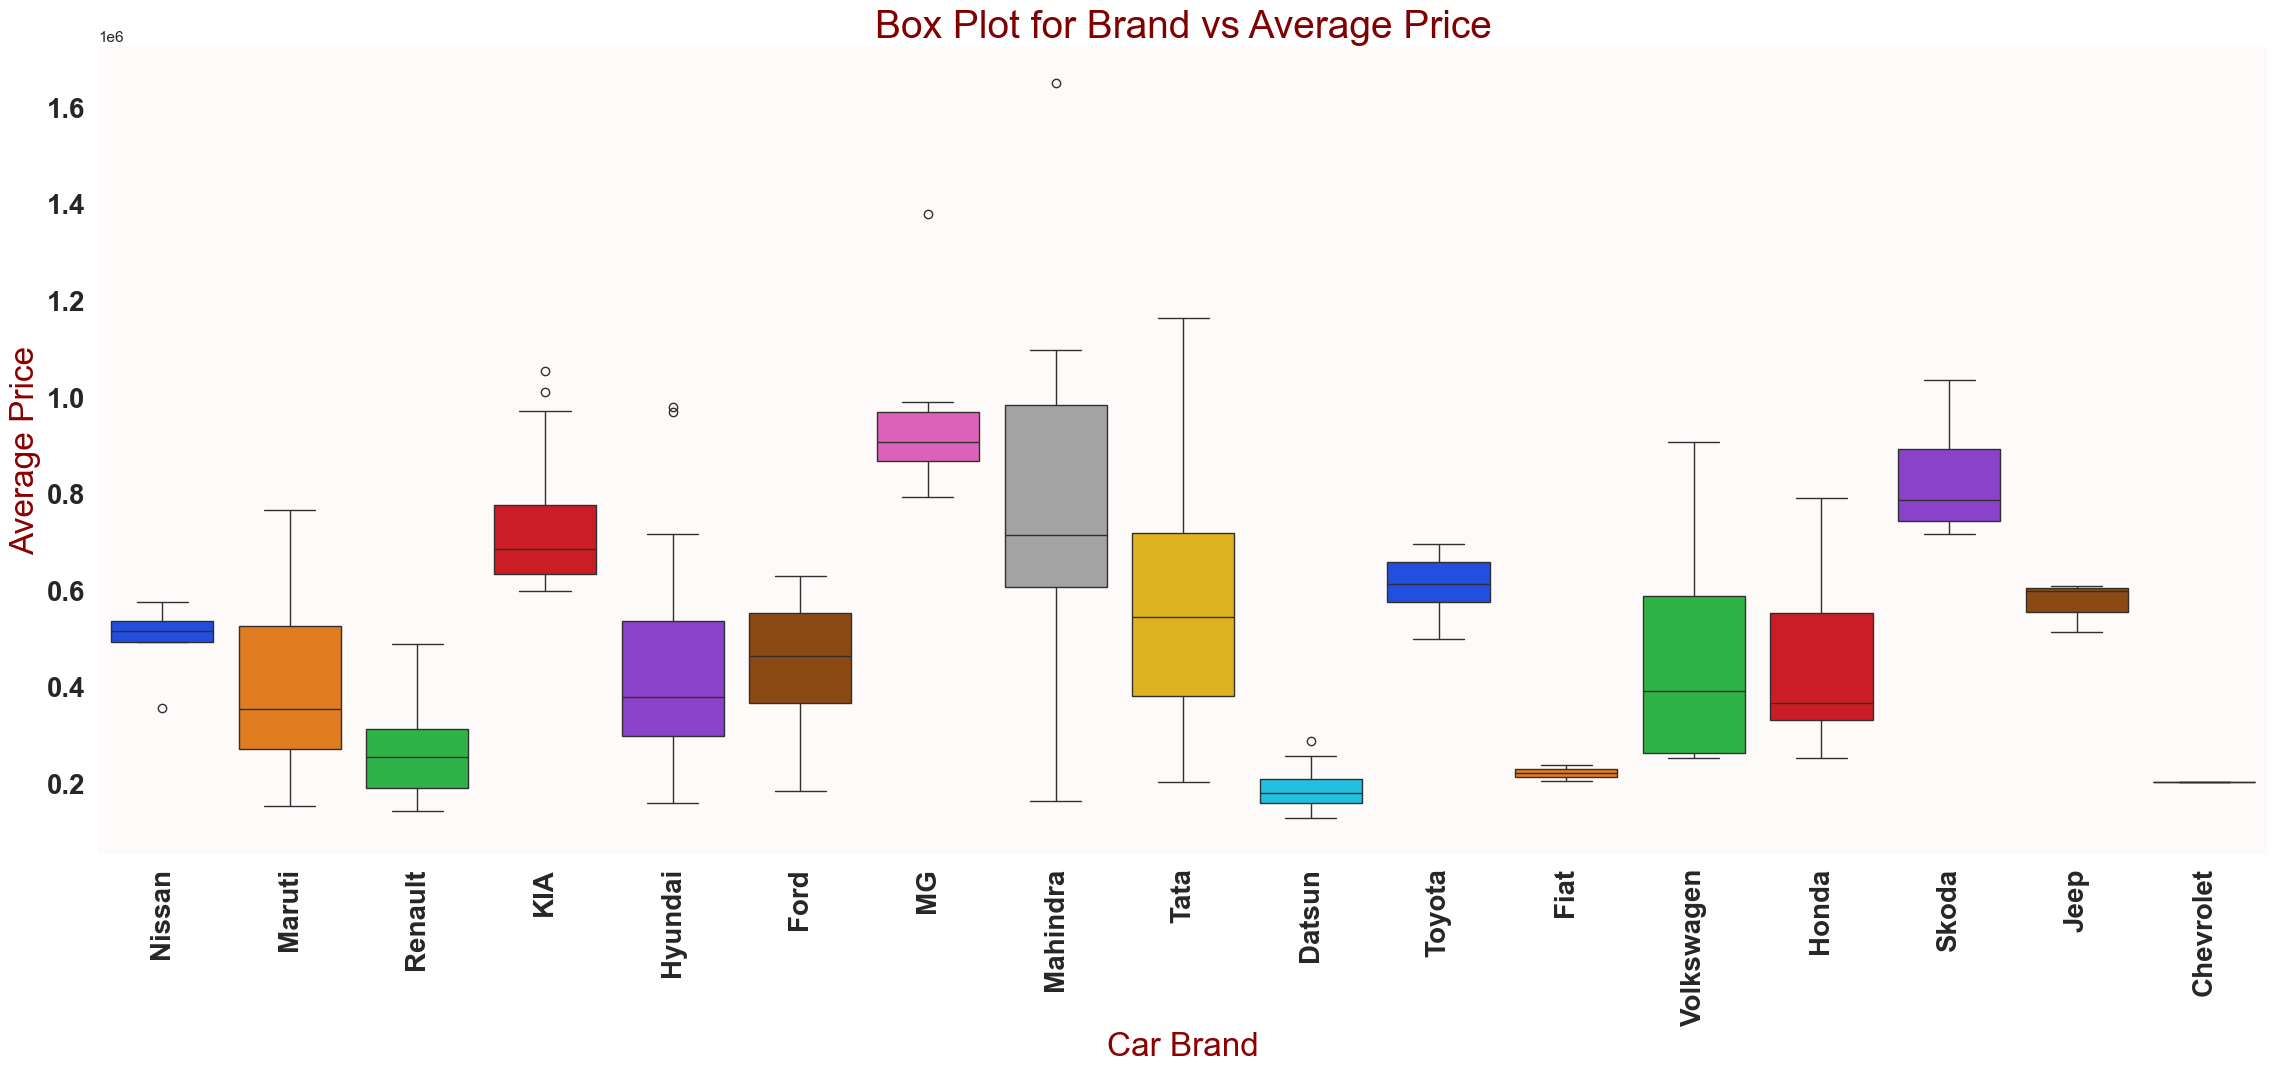

In [94]:
sns.set(rc={'figure.figsize':(28,10.5)})
a = sns.boxplot(x='Brand',y='price',data=df,palette='bright')
a.set_xlabel("Car Brand", fontsize = 24,color='darkred')
a.set_ylabel("Average Price", fontsize =24, color='darkred')
plt.xticks(rotation=90,fontsize=20,fontweight='bold')
plt.yticks(fontsize=20,fontweight='bold')
a.set_title("Box Plot for Brand vs Average Price", fontsize =28, color='maroon')
a.set_facecolor('snow')
a.grid(False)
plt.show()

## 16) Heat Map for Correlation 

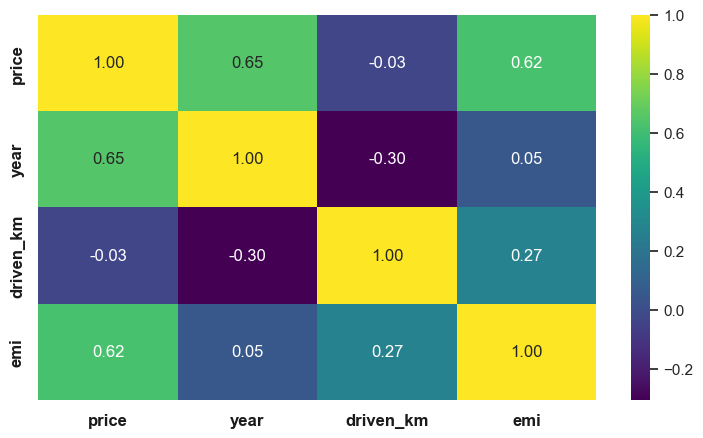

In [97]:
corr_df = df[['price', 'year', 'driven_km', 'emi']].corr()

sns.set(rc={'figure.figsize': (9, 5)})

sns.heatmap(
    corr_df,
    annot=True,
    cmap='viridis',
    fmt='.2f'
)

plt.xticks(fontsize=12, color='k', fontweight='bold')
plt.yticks(fontsize=12, color='k', fontweight='bold')
plt.show()